<a href="https://colab.research.google.com/github/Lawson-Dong/ESINDy_infra/blob/main/Bagging_and_Boosting_and_Stacking(Lorenz_96_and_Duffing).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting Experiment: Lorenz 96 (High-Dimensional Chaos)
Running Benchmark: Lorenz96 (10 runs per setting)

--- Noise Level: sigma = 0.0 ---
  Bagging    -> Avg RMSE: 0.072399 ± 0.001555, Avg Time: 5.88s ± 0.83s
  Boosting   -> Avg RMSE: 0.068541 ± 0.001321, Avg Time: 3.35s ± 0.65s
  Stacking   -> Avg RMSE: 0.000582 ± 0.000094, Avg Time: 7.39s ± 0.82s

--- Noise Level: sigma = 0.1 ---
  Bagging    -> Avg RMSE: 0.066929 ± 0.002545, Avg Time: 5.96s ± 0.32s
  Boosting   -> Avg RMSE: 0.065895 ± 0.002158, Avg Time: 4.02s ± 0.72s
  Stacking   -> Avg RMSE: 0.007431 ± 0.006821, Avg Time: 7.79s ± 0.38s

--- Noise Level: sigma = 0.3 ---
  Bagging    -> Avg RMSE: 0.076635 ± 0.013100, Avg Time: 11.05s ± 5.96s
  Boosting   -> Avg RMSE: 0.078702 ± 0.015403, Avg Time: 5.38s ± 2.03s
  Stacking   -> Avg RMSE: 0.032192 ± 0.034545, Avg Time: 11.76s ± 5.30s

--- Noise Level: sigma = 0.5 ---
  Bagging    -> Avg RMSE: 0.124207 ± 0.024675, Avg Time: 11.40s ± 4.00s
  Boosting   -> Avg RMSE: 0.107309 ± 0.012587

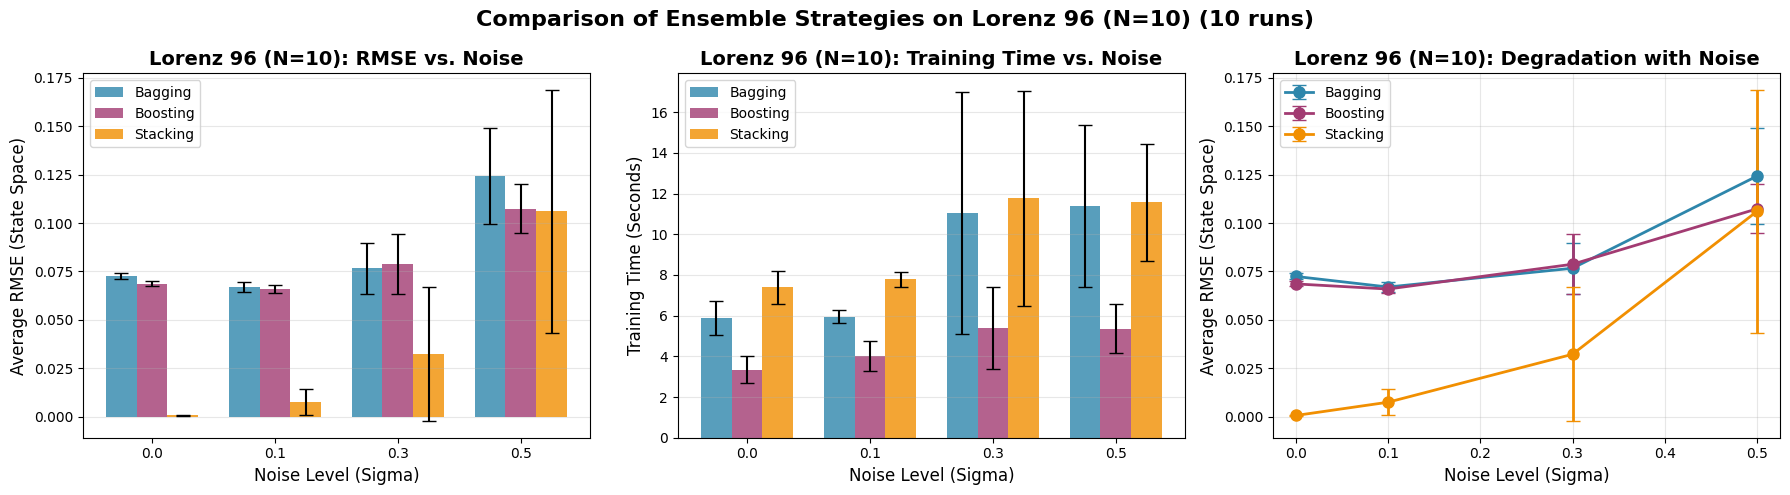



Starting Experiment: Duffing Oscillator
Running Benchmark: Duffing (10 runs per setting)

--- Noise Level: sigma = 0.0 ---
  Bagging    -> Avg RMSE: 0.009681 ± 0.000002, Avg Time: 0.16s ± 0.03s
  Boosting   -> Avg RMSE: 0.009811 ± 0.000000, Avg Time: 0.07s ± 0.02s
  Stacking   -> Avg RMSE: 0.009250 ± 0.000000, Avg Time: 0.15s ± 0.03s

--- Noise Level: sigma = 0.1 ---
  Bagging    -> Avg RMSE: 0.009679 ± 0.000006, Avg Time: 0.15s ± 0.03s
  Boosting   -> Avg RMSE: 0.009820 ± 0.000008, Avg Time: 0.07s ± 0.01s
  Stacking   -> Avg RMSE: 0.009250 ± 0.000025, Avg Time: 0.13s ± 0.01s

--- Noise Level: sigma = 0.3 ---
  Bagging    -> Avg RMSE: 0.009686 ± 0.000029, Avg Time: 0.16s ± 0.02s
  Boosting   -> Avg RMSE: 0.009926 ± 0.000062, Avg Time: 0.07s ± 0.01s
  Stacking   -> Avg RMSE: 0.008878 ± 0.000441, Avg Time: 0.16s ± 0.04s

--- Noise Level: sigma = 0.5 ---
  Bagging    -> Avg RMSE: 0.009674 ± 0.000564, Avg Time: 0.17s ± 0.03s
  Boosting   -> Avg RMSE: 0.010184 ± 0.000337, Avg Time: 0.06s 

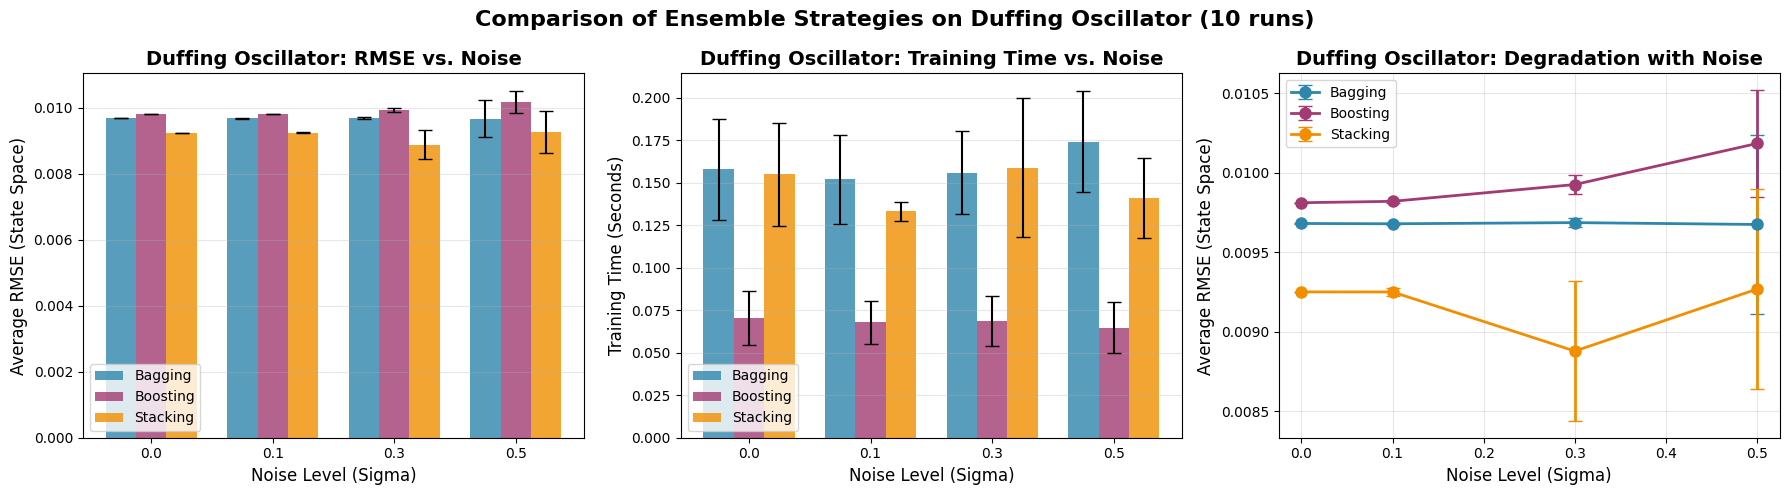

Experiment completed successfully!


In [1]:
# =============================================================================
# Part 1: Import Libraries and Setup
# =============================================================================
!pip install scikit-learn matplotlib numpy scipy -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.signal import savgol_filter
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from itertools import combinations_with_replacement
import warnings
import time

warnings.filterwarnings('ignore')

# =============================================================================
# Part 2: Base SINDy Framework (Fixed __init__ logic)
# =============================================================================

class BaseSINDy:
    """Base class for SINDy with common utility functions."""
    def __init__(self, **kwargs):
        self.poly_degree = kwargs.get('poly_degree', 2)
        self.threshold = kwargs.get('threshold', 0.15)
        self.sg_window = kwargs.get('sg_window', 11)
        self.sg_order = kwargs.get('sg_order', 3)
        self.use_reduced_features = kwargs.get('use_reduced_features', False)
        self.feature_names = None
        self.poly = None

    def _compute_derivative_sg(self, X, dt):
        """Compute robust derivatives using Savitzky-Golay filter."""
        n_samples, n_states = X.shape
        dX = np.zeros_like(X)
        for i in range(n_states):
            X_smoothed = savgol_filter(X[:, i], self.sg_window, self.sg_order)
            dX[:, i] = np.gradient(X_smoothed, dt)
        return dX

    def _create_polynomial_features(self, X, fit=False):
        """Create polynomial feature library."""
        if self.use_reduced_features:
            return self._create_reduced_features(X)
        else:
            if fit or not hasattr(self, 'poly'):
                self.poly = PolynomialFeatures(degree=self.poly_degree, include_bias=False)
                Theta = self.poly.fit_transform(X)
            else:
                Theta = self.poly.transform(X)
            return Theta

    def _create_reduced_features(self, X):
        """Default placeholder for reduced library if needed."""
        if not hasattr(self, 'poly'):
            self.poly = PolynomialFeatures(degree=self.poly_degree, include_bias=False)
            Theta = self.poly.fit_transform(X)
        else:
            Theta = self.poly.transform(X)
        return Theta

class BaggingSINDy(BaseSINDy):
    """Bagging Ensemble SINDy."""
    def __init__(self, **kwargs):
        self.n_estimators = kwargs.pop('n_estimators', 50)
        self.subsample_ratio = kwargs.pop('subsample_ratio', 0.8)
        self.noise_std = kwargs.pop('noise_std', 0.05)
        self.models = []
        self.final_coefficients = None
        super().__init__(**kwargs)

    def fit(self, X, dt, verbose=False):
        n_samples, n_states = X.shape
        dX = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X, fit=True)
        self.models = []

        for i in range(self.n_estimators):
            try:
                indices = np.random.choice(n_samples, int(n_samples * self.subsample_ratio), replace=True)
                Theta_sample = Theta[indices].copy()
                dX_sample = dX[indices].copy()
                if self.noise_std > 0:
                    Theta_sample += np.random.normal(0, self.noise_std, Theta_sample.shape)
                    dX_sample += np.random.normal(0, self.noise_std, dX_sample.shape)

                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta_sample, dX_sample[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                self.models.append(np.array(coeffs))
            except Exception:
                continue

        if len(self.models) == 0:
            raise RuntimeError("All models failed to train.")
        self.final_coefficients = np.median(self.models, axis=0)
        return self

    def predict_derivative(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        Theta = self._create_polynomial_features(X, fit=False)
        return Theta @ self.final_coefficients.T

class BoostingSINDy(BaseSINDy):
    """Boosting Ensemble SINDy with early stopping."""
    def __init__(self, **kwargs):
        self.n_estimators = kwargs.pop('n_estimators', 50)
        self.learning_rate = kwargs.pop('learning_rate', 0.1)
        # --- 新增：早停相关参数 ---
        self.early_stopping = kwargs.pop('early_stopping', True)
        self.early_stopping_tol = kwargs.pop('early_stopping_tol', 1e-4)
        self.patience = kwargs.pop('patience', 5)
        # -------------------------
        self.models = []
        self.final_coefficients = None
        super().__init__(**kwargs)

    def fit(self, X, dt, verbose=False):
        n_samples, n_states = X.shape
        dX_true = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X, fit=True)
        self.final_coefficients = np.zeros((n_states, Theta.shape[1]))
        self.models = []
        dX_residual = dX_true.copy()

        # 早停监控变量
        best_loss = np.inf
        patience_counter = 0

        for i in range(self.n_estimators):
            try:
                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta, dX_residual[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                coeffs = np.array(coeffs)

                # 更新最终系数和残差
                self.final_coefficients += self.learning_rate * coeffs
                dX_pred = Theta @ coeffs.T
                dX_residual -= self.learning_rate * dX_pred

                # 早停检查
                if self.early_stopping:
                    current_loss = np.mean(dX_residual**2)
                    # 相对改善小于阈值则计数
                    if (best_loss - current_loss) / (best_loss + 1e-10) < self.early_stopping_tol:
                        patience_counter += 1
                        if patience_counter >= self.patience:
                            if verbose:
                                print(f"Early stopping at iteration {i}, loss = {current_loss:.6f}")
                            break
                    else:
                        best_loss = current_loss
                        patience_counter = 0

                self.models.append(coeffs)
            except Exception:
                continue
        return self

    def predict_derivative(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        Theta = self._create_polynomial_features(X, fit=False)
        return Theta @ self.final_coefficients.T

class StackingSINDy(BaseSINDy):
    """Stacking Ensemble SINDy."""
    def __init__(self, **kwargs):
        self.n_estimators = kwargs.pop('n_estimators', 50)
        self.n_folds = kwargs.pop('n_folds', 5)
        self.meta_alpha = kwargs.pop('meta_alpha', 1.0)
        self.base_models = []
        self.meta_models = []
        self.final_coefficients = None
        super().__init__(**kwargs)

    def fit(self, X, dt, verbose=False):
        n_samples, n_states = X.shape
        dX = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X, fit=True)
        n_features = Theta.shape[1]
        self.base_models = []
        base_predictions = []

        for i in range(self.n_estimators):
            try:
                train_idx = np.random.choice(n_samples, int(n_samples * 0.8), replace=False)
                Theta_train = Theta[train_idx]
                dX_train = dX[train_idx]

                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta_train, dX_train[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                coeffs = np.array(coeffs)
                self.base_models.append(coeffs)
                base_predictions.append(Theta @ coeffs.T)
            except Exception:
                continue

        if len(self.base_models) == 0:
            raise RuntimeError("All base models failed.")

        base_predictions = np.array(base_predictions)
        self.final_coefficients = np.zeros((n_states, n_features))
        self.meta_models = []

        for j in range(n_states):
            X_meta = base_predictions[:, :, j].T
            y_meta = dX[:, j]
            meta_model = Ridge(alpha=self.meta_alpha)
            meta_model.fit(X_meta, y_meta)
            self.meta_models.append(meta_model)
            meta_weights = meta_model.coef_
            weighted_coeffs = np.zeros(n_features)
            for k, w in enumerate(meta_weights):
                if k < len(self.base_models):
                    weighted_coeffs += w * self.base_models[k][j]
            self.final_coefficients[j] = weighted_coeffs / (np.sum(np.abs(meta_weights)) + 1e-10)
        return self

    def predict_derivative(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        Theta = self._create_polynomial_features(X, fit=False)
        base_preds = []
        for model in self.base_models:
            base_preds.append(Theta @ model.T)
        base_preds = np.array(base_preds)
        n_samples = X.shape[0]
        n_states = self.final_coefficients.shape[0]
        final_pred = np.zeros((n_samples, n_states))
        for j in range(n_states):
            X_meta = base_preds[:, :, j].T
            final_pred[:, j] = self.meta_models[j].predict(X_meta)
        return final_pred

# =============================================================================
# Part 3: Benchmark Systems Definition (with seed parameter for reproducibility)
# =============================================================================

def generate_lorenz96_data(N=10, F=8.0, t_max=10.0, dt=0.01, x0=None, noise_std=0.0, seed=None):
    """Generate Lorenz 96 system data with optional random seed."""
    rng = np.random.RandomState(seed) if seed is not None else np.random

    def lorenz96_system(x, t):
        dxdt = np.zeros_like(x)
        for i in range(N):
            dxdt[i] = (x[(i+1)%N] - x[(i-2)%N]) * x[(i-1)%N] - x[i] + F
        return dxdt

    t = np.arange(0, t_max, dt)
    if x0 is None:
        x0 = rng.uniform(-1, 1, N)

    X_true = odeint(lorenz96_system, x0, t)
    if noise_std > 0:
        X_noisy = X_true + rng.normal(0, noise_std, X_true.shape)
    else:
        X_noisy = X_true
    return t, X_true, X_noisy

def generate_duffing_data(delta=0.3, gamma=1.2, t_max=10.0, dt=0.01, x0=[1.0, 0.0], noise_std=0.0, seed=None):
    """Generate Duffing Oscillator data with optional random seed."""
    rng = np.random.RandomState(seed) if seed is not None else np.random

    def duffing_system(state, t):
        x, y = state
        dx = y
        dy = x - x**3 - delta * y + gamma * np.cos(t)
        return [dx, dy]

    t = np.arange(0, t_max, dt)
    X_true = odeint(duffing_system, x0, t)
    if noise_std > 0:
        X_noisy = X_true + rng.normal(0, noise_std, X_true.shape)
    else:
        X_noisy = X_true
    return t, X_true, X_noisy

# =============================================================================
# Part 4: Integration and Evaluation Functions
# =============================================================================

def one_step_prediction_rk4(model, X_test_true, dt):
    """Run one-step prediction using RK4 integration."""
    n_steps = len(X_test_true)
    X_pred = np.zeros_like(X_test_true)
    X_pred[0] = X_test_true[0]

    def f(state):
        if state.ndim == 1:
            state = state.reshape(1, -1)
        return model.predict_derivative(state)[0]

    for i in range(n_steps - 1):
        x = X_test_true[i].flatten()
        k1 = f(x)
        if np.any(np.isnan(k1)): continue
        k2 = f(x + 0.5 * dt * k1)
        k3 = f(x + 0.5 * dt * k2)
        k4 = f(x + dt * k3)
        if np.any(np.isnan(k2)) or np.any(np.isnan(k3)) or np.any(np.isnan(k4)):
            continue
        X_pred[i+1] = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return X_pred

def calculate_rmse(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if np.sum(mask) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

# =============================================================================
# Part 5: Main Experiment Runner (Modified for multiple runs)
# =============================================================================

def run_experiment_for_system(system_name, generate_data_func, config, X0_test, noise_levels, n_runs=10, verbose=True):
    """
    对每个噪声水平、每种集成方法进行 n_runs 次独立实验，
    计算平均 RMSE 和平均训练时间，并保留标准差用于绘图。
    """
    methods = ['bagging', 'boosting', 'stacking']
    # 初始化结果字典：每个方法对应四个指标列表（每个噪声水平一个值）
    results = {m: {'rmse_avg': [], 'rmse_std': [], 'time_avg': [], 'time_std': []} for m in methods}

    if verbose:
        print(f"Running Benchmark: {system_name} ({n_runs} runs per setting)")
        print("="*80)

    # 生成清洁测试数据（只生成一次，所有实验共用）
    _, X_true_test, _ = generate_data_func(noise_std=0, **config['system_kwargs'])
    eval_steps = int(config['eval_window'] / config['dt'])
    X_true_test_eval = X_true_test[:eval_steps]

    for noise_std in noise_levels:
        if verbose:
            print(f"\n--- Noise Level: sigma = {noise_std} ---")

        # 为每种方法准备存储多次运行结果的列表
        runs_rmse = {m: [] for m in methods}
        runs_time = {m: [] for m in methods}

        for run in range(n_runs):
            # 使用不同种子保证每次噪声实现不同
            seed = run + int(noise_std*1000)  # 简单混合以避免不同噪声水平下种子重复
            _, _, X_noisy_train = generate_data_func(noise_std=noise_std, seed=seed, **config['system_kwargs'])

            for method_name in methods:
                # 初始化模型
                if method_name == 'bagging':
                    model = BaggingSINDy(**config['sindy_kwargs'])
                elif method_name == 'boosting':
                    model = BoostingSINDy(**config['sindy_kwargs'])
                else:
                    model = StackingSINDy(**config['sindy_kwargs'])

                start_time = time.time()
                model.fit(X_noisy_train, dt=config['dt'], verbose=False)
                elapsed = time.time() - start_time

                X_pred = one_step_prediction_rk4(model, X_true_test_eval, config['dt'])
                rmse = calculate_rmse(X_true_test_eval.flatten(), X_pred.flatten())

                runs_rmse[method_name].append(rmse)
                runs_time[method_name].append(elapsed)

        # 计算每个方法在当前噪声水平下的统计量
        for m in methods:
            results[m]['rmse_avg'].append(np.mean(runs_rmse[m]))
            results[m]['rmse_std'].append(np.std(runs_rmse[m]))
            results[m]['time_avg'].append(np.mean(runs_time[m]))
            results[m]['time_std'].append(np.std(runs_time[m]))

        if verbose:
            for m in methods:
                avg_rmse = results[m]['rmse_avg'][-1]
                avg_time = results[m]['time_avg'][-1]
                print(f"  {m.capitalize():10s} -> Avg RMSE: {avg_rmse:.6f} ± {results[m]['rmse_std'][-1]:.6f}, "
                      f"Avg Time: {avg_time:.2f}s ± {results[m]['time_std'][-1]:.2f}s")

    return results

# =============================================================================
# Part 6: Visualization Functions (Updated with error bars)
# =============================================================================

def plot_benchmark_results(results, system_name, noise_levels):
    """绘制带误差棒的对比图：RMSE条形图、训练时间条形图、RMSE趋势线"""
    methods = ['bagging', 'boosting', 'stacking']
    method_names = ['Bagging', 'Boosting', 'Stacking']
    colors = ['#2E86AB', '#A23B72', '#F18F01']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    x_pos = np.arange(len(noise_levels))
    width = 0.25

    # 1. RMSE 条形图（带误差棒）
    ax = axes[0]
    for i, m in enumerate(methods):
        means = results[m]['rmse_avg']
        stds = results[m]['rmse_std']
        ax.bar(x_pos + i*width, means, width, yerr=stds, capsize=5,
               label=method_names[i], color=colors[i], alpha=0.8)
    ax.set_xlabel('Noise Level (Sigma)', fontsize=12)
    ax.set_ylabel('Average RMSE (State Space)', fontsize=12)
    ax.set_title(f'{system_name}: RMSE vs. Noise', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # 2. Training Time 条形图（带误差棒）
    ax = axes[1]
    for i, m in enumerate(methods):
        means = results[m]['time_avg']
        stds = results[m]['time_std']
        ax.bar(x_pos + i*width, means, width, yerr=stds, capsize=5,
               label=method_names[i], color=colors[i], alpha=0.8)
    ax.set_xlabel('Noise Level (Sigma)', fontsize=12)
    ax.set_ylabel('Training Time (Seconds)', fontsize=12)
    ax.set_title(f'{system_name}: Training Time vs. Noise', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # 3. RMSE 趋势线（带误差阴影）
    ax = axes[2]
    for i, m in enumerate(methods):
        means = results[m]['rmse_avg']
        stds = results[m]['rmse_std']
        ax.errorbar(noise_levels, means, yerr=stds, fmt='o-', label=method_names[i],
                    color=colors[i], linewidth=2, markersize=8, capsize=5)
    ax.set_xlabel('Noise Level (Sigma)', fontsize=12)
    ax.set_ylabel('Average RMSE (State Space)', fontsize=12)
    ax.set_title(f'{system_name}: Degradation with Noise', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'Comparison of Ensemble Strategies on {system_name} (10 runs)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =============================================================================
# Part 7: Execution
# =============================================================================

# 基础配置（包含 Boosting 早停参数，其他方法会忽略）
base_config = {
    'dt': 0.01,
    'eval_window': 5.0,
    'sindy_kwargs': {
        'poly_degree': 2,
        'threshold': 0.15,
        'sg_window': 11,
        'sg_order': 3,
        'n_estimators': 50,           # 可适当增加，早停会提前终止
        'use_reduced_features': False,
        'learning_rate': 0.1,
        # Boosting 早停设置
        'early_stopping': True,
        'early_stopping_tol': 1e-4,
        'patience': 5
    }
}

# 待测试的噪声水平列表
noise_levels = [0.0, 0.1, 0.3, 0.5]

# --- Benchmark 1: Lorenz 96 ---
lorenz96_config = base_config.copy()
lorenz96_config['system_kwargs'] = {'N': 10, 'F': 8.0, 't_max': 10.0}

print("Starting Experiment: Lorenz 96 (High-Dimensional Chaos)")
lorenz96_results = run_experiment_for_system(
    system_name="Lorenz96",
    generate_data_func=generate_lorenz96_data,
    config=lorenz96_config,
    X0_test=None,               # 内部随机生成
    noise_levels=noise_levels,
    n_runs=10,                  # 每种设置 10 次独立实验
    verbose=True
)
plot_benchmark_results(lorenz96_results, "Lorenz 96 (N=10)", noise_levels)

# --- Benchmark 2: Duffing Oscillator ---
duffing_config = base_config.copy()
duffing_config['system_kwargs'] = {'delta': 0.3, 'gamma': 1.2, 't_max': 15.0}

print("\n\nStarting Experiment: Duffing Oscillator")
duffing_results = run_experiment_for_system(
    system_name="Duffing",
    generate_data_func=generate_duffing_data,
    config=duffing_config,
    X0_test=[1.0, 0.0],
    noise_levels=noise_levels,
    n_runs=10,
    verbose=True
)
plot_benchmark_results(duffing_results, "Duffing Oscillator", noise_levels)

print("Experiment completed successfully!")